In [22]:
%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
from py_files.capinc import CapIncModel

import py_files.simulation_1 as simulation_1
import py_files.simulation_2 as simulation_2 
import py_files.simulation_3 as simulation_3
import py_files.var_groups as var_groups
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import math
from io import StringIO
import requests
import py_files.fig_setup as fs
import matplotlib.ticker as mticker

importlib.reload(fs)     
fs.set_aej()    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# `Interest rate` data fetch

Possible source for addition: https://www.oecd.org/en/data/datasets/corporate-income-tax-rates-database.html
- Corporate income tax (CIT) - statutory and targeted small business rates
- 2000: 32% and 2025: 22%

https://data-explorer.oecd.org/vis?fs[0]=Topic%2C1%7CTaxation%23TAX%23%7CCorporate%20tax%23TAX_CPT%23&pg=0&fc=Topic&bp=true&snb=19&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_TAX_CIT%40DF_CIT&df[ag]=OECD.CTP.TPS&df[vs]=2.0&dq=DNK.A.CIT.ST..S13%2BS1311%2BS13M...&pd=2000%2C2025&to[TIME_PERIOD]=false&vw=tl

Using API, I get CIT data for DK from 2020-2025:

In [20]:
url = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.CTP.TPS,DSD_TAX_CIT@DF_CIT,1.0/"
    "DNK.A..ST..S13+S1311+S13M.."
    "?startPeriod=2000&endPeriod=2025"
    "&dimensionAtObservation=AllDimensions"
    "&format=csvfilewithlabels"
)

r = requests.get(url)

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))

# keep only the statutory CIT rate
df_cit = (df.loc[df["MEASURE"] == "CIT", ["TIME_PERIOD", "OBS_VALUE"]]
            .rename(columns={"TIME_PERIOD": "year", "OBS_VALUE": "cit_rate"})
            .assign(year=lambda x: x["year"].astype(int))
            .sort_values("year")
            .reset_index(drop=True))

cit_ = df_cit["cit_rate"].to_numpy(dtype=float)

cit = cit_/100
tau_t = np.concatenate([cit, np.full(10, cit[-1])])
dlog = np.log(tau_t / cit[0])

*compare with alternative path $\{\tau\}_t^T$, here following*
$$
    1 + \tau_t = (1-\tau_T) +\rho^t [(1-\tau_0) - (1-\tau_T)].
$$

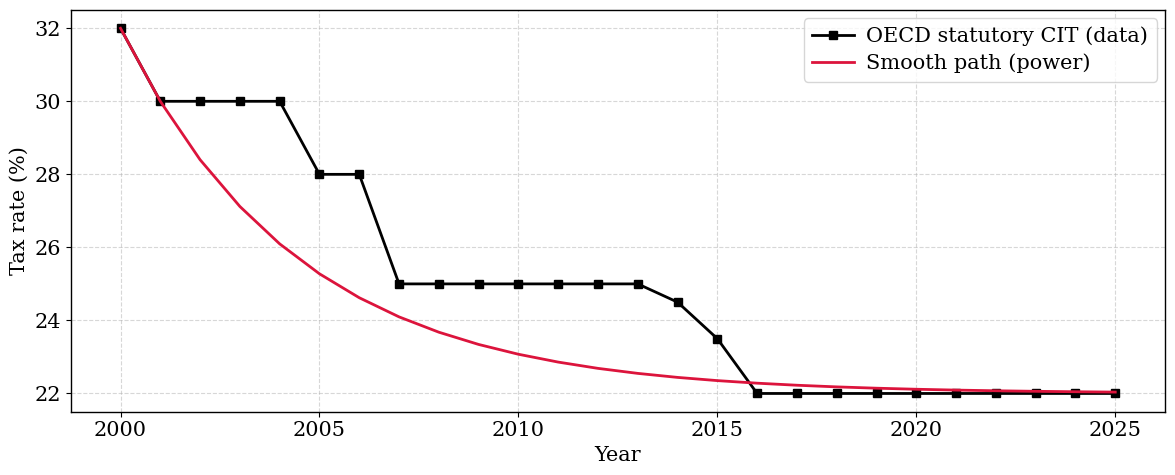

In [23]:
y0 = int(df_cit["year"].min())
yT = int(df_cit["year"].max())
T  = yT - y0

tau0 = df_cit.loc[df_cit["year"] == y0, "cit_rate"].iloc[0] / 100
tauT = df_cit.loc[df_cit["year"] == yT, "cit_rate"].iloc[0] / 100

_, tau_t, _ = simulation_2.net_tax_path_ar1(rho=0.8)
years_model = np.arange(y0, yT + 1)

# --- plot ---
plt.figure(figsize=(12, 5))
plt.plot(df_cit["year"], df_cit["cit_rate"], linewidth=2, marker="s", label="OECD statutory CIT (data)", color='k')
plt.plot(years_model, 100 * tau_t, linewidth=2, label=r"Smooth path (power)", color='crimson')
plt.xlabel("Year")
plt.ylabel("Tax rate (%)")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

> not the right function, should approach the final value with less slope at the end.

*make alternative simulation, using empirical-like path*

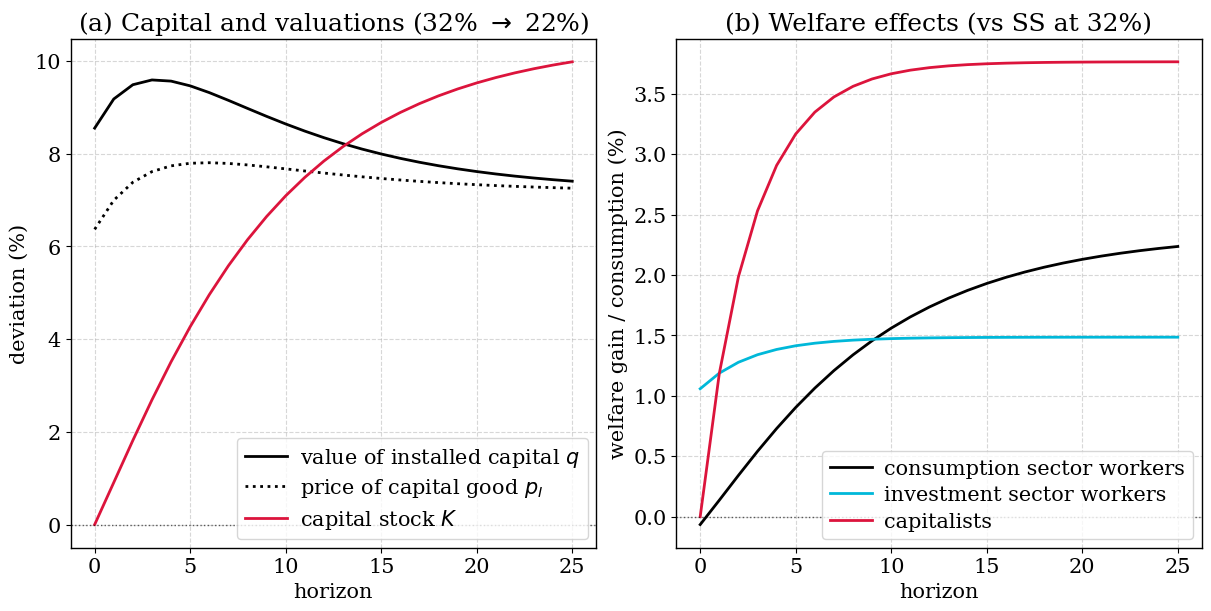

In [28]:
# run
m = CapIncModel()

fig, axes, ss, sim, meta = simulation_2.plot_figure5_reform(
    m, T=25, tau_ss=0.32, tauT=0.22, rho=0.7, tail=50
)
plt.show()

*... with actual empirical path*

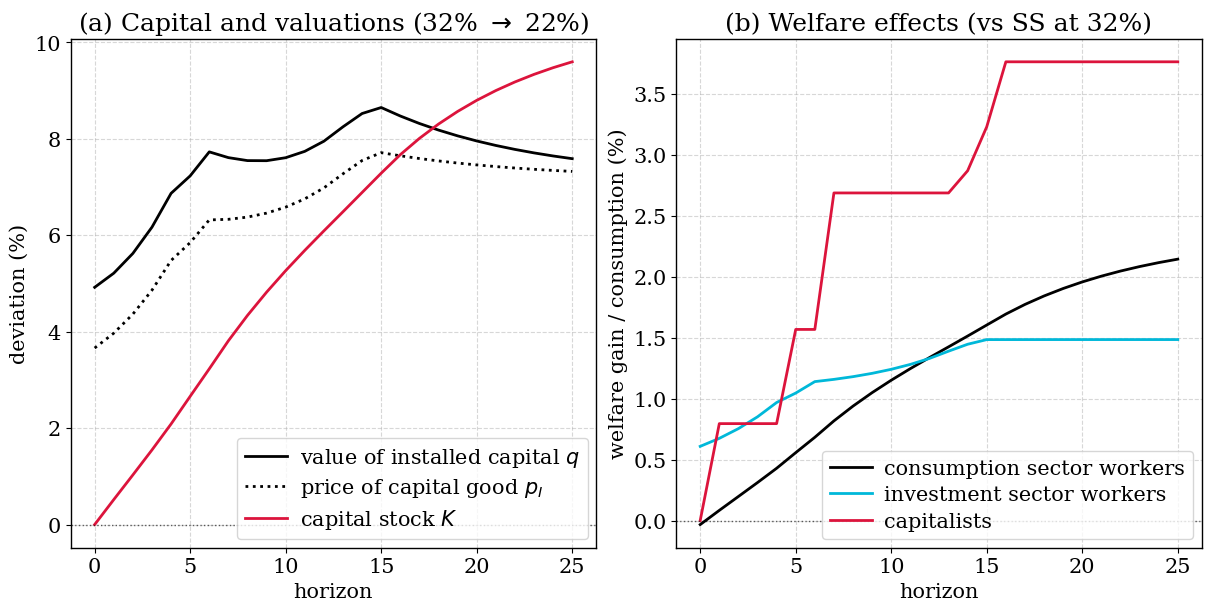

In [43]:
fig, axes, ss, sim, meta = simulation_3.plot_figure5_emp(m)
plt.show()

tau_t_emp = meta['tau_t']
tau_emp = np.concatenate([tau_t_test, np.full(50, tau_t_test[-1])])

*and assess the labour share*

In [46]:
gamma  = 0.6
T_plot = 25
tail   = 50
T_solve = T_plot + tail

tau0  = 0.32
tauT  = 0.22
rho   = 0.7

m = CapIncModel()

# anchor baseline SS at tau0
ss0 = m.solve_steady_state(tau=tau0)
ss1 = m.solve_steady_state(tau=tauT)

# paths (LONG)
_, tau_t1_long, _ = simulation_2.net_tax_path_ar1(T=T_solve, tau0=tau0, tauT=tauT, rho=rho, T_reform=25)
tau_t2_long = np.full_like(tau_t1_long, tau0)
tau_t3_long = np.full_like(tau_t1_long, tauT)

# guesses must match LONG length
qg0 = np.full(T_solve + 1, ss0["q"])
qg1 = np.full(T_solve + 1, ss1["q"])

# reform: smoothed
sim1 = m.solve_transition(tau_path=tau_t1_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tauT)
ls1_full = simulation_2.labour_share(m, sim1, gamma=gamma)

# reform: empirical
sim4 = m.solve_transition(tau_path=tau_emp, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tauT)
ls4_full = simulation_2.labour_share(m, sim4, gamma=gamma)

# baseline: close at tau0 and START from tau0 SS
sim2 = m.solve_transition(tau_path=tau_t2_long, K0=ss0["K"],
                          q_guess_path=qg0, tau_terminal=tau0)
ls2_full = simulation_2.labour_share(m, sim2, gamma=gamma)

# endpoint: start+close at tauT SS
sim3 = m.solve_transition(tau_path=tau_t3_long, K0=ss1["K"],
                          q_guess_path=qg1, tau_terminal=tauT)
ls3_full = simulation_2.labour_share(m, sim3, gamma=gamma)

# TRUNCATE for plotting
sl = slice(0, T_plot + 1)
ls1 = {k: np.asarray(v)[sl] for k, v in ls1_full.items()}
ls2 = {k: np.asarray(v)[sl] for k, v in ls2_full.items()}
ls3 = {k: np.asarray(v)[sl] for k, v in ls3_full.items()}
ls4 = {k: np.asarray(v)[sl] for k, v in ls4_full.items()}
h = np.arange(T_plot + 1)

c:\Users\LinusLindquist\anaconda3\Lib\site-packages\scipy\optimize\_nonlin.py:374: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


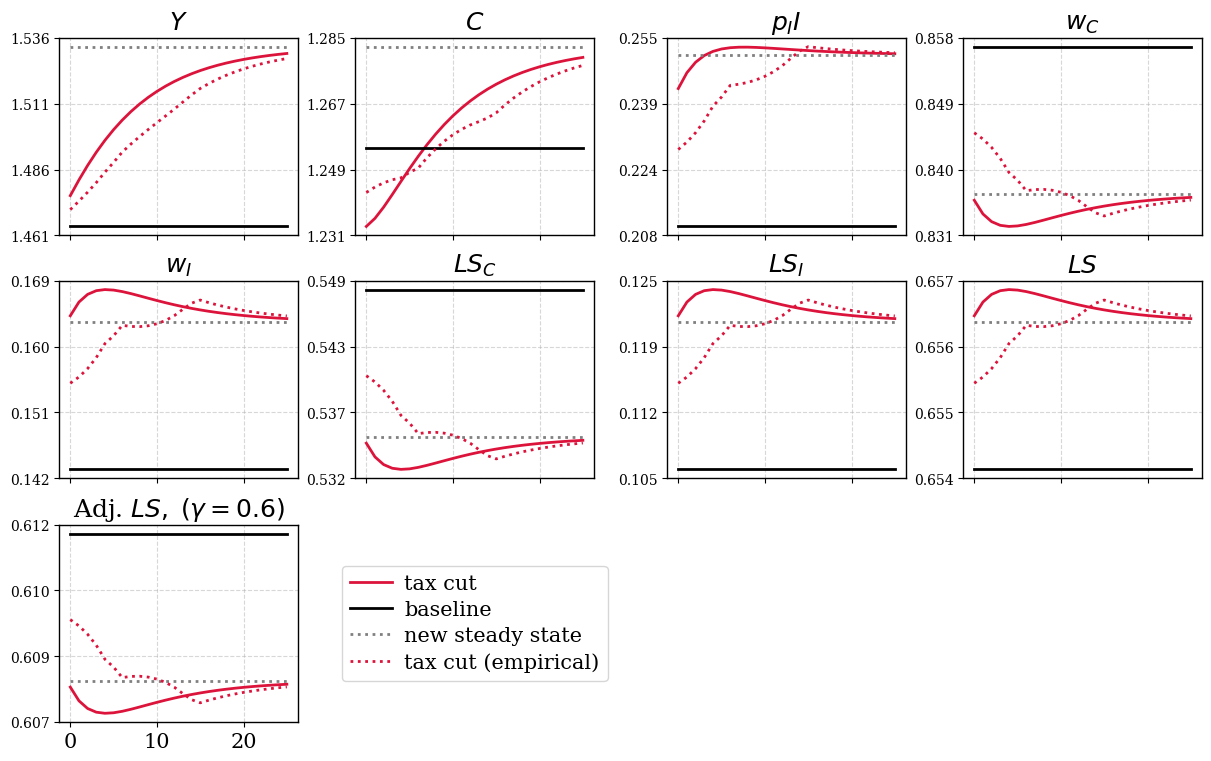

In [47]:
ncols, nrows = 4, 3

fig, axes = plt.subplots(3, 4, figsize=(12, 2.5*nrows), sharex=True, constrained_layout=True)
axes = axes.ravel()

panels = list(var_groups.panels(gamma))   # list of (k, ttl)
n_used = len(panels)

# plot used panels
for i, (k, ttl) in enumerate(panels):
    ax = axes[i]
    ax.plot(h, ls1[k], lw=2, color="crimson")
    ax.plot(h, ls2[k], lw=2, color="k")
    ax.plot(h, ls3[k], lw=2, color="gray", ls=":")
    ax.plot(h, ls4[k], lw=2, color="crimson", ls=":")
    ax.set_title(ttl)
    # ax.set_xlabel("horizon")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.tick_params(axis="y", labelsize=10)

# hide empty panels
for j in range(n_used, len(axes)):
    axes[j].set_axis_off()

# put legend in first empty panel (if any)
if n_used < len(axes):
    ax_leg = axes[n_used]
    ax_leg.set_axis_off()

    h1 = plt.Line2D([0], [0], color="crimson", lw=2)
    h2 = plt.Line2D([0], [0], color="k", lw=2)
    h3 = plt.Line2D([0], [0], color="gray", lw=2, ls=":")
    h4 = plt.Line2D([0], [0], color="crimson", lw=2, ls=":")

    ax_leg.legend([h1, h2, h3, h4],
                  ["tax cut", "baseline", "new steady state", 'tax cut (empirical)'],
                  loc="center", frameon=True)

plt.show()

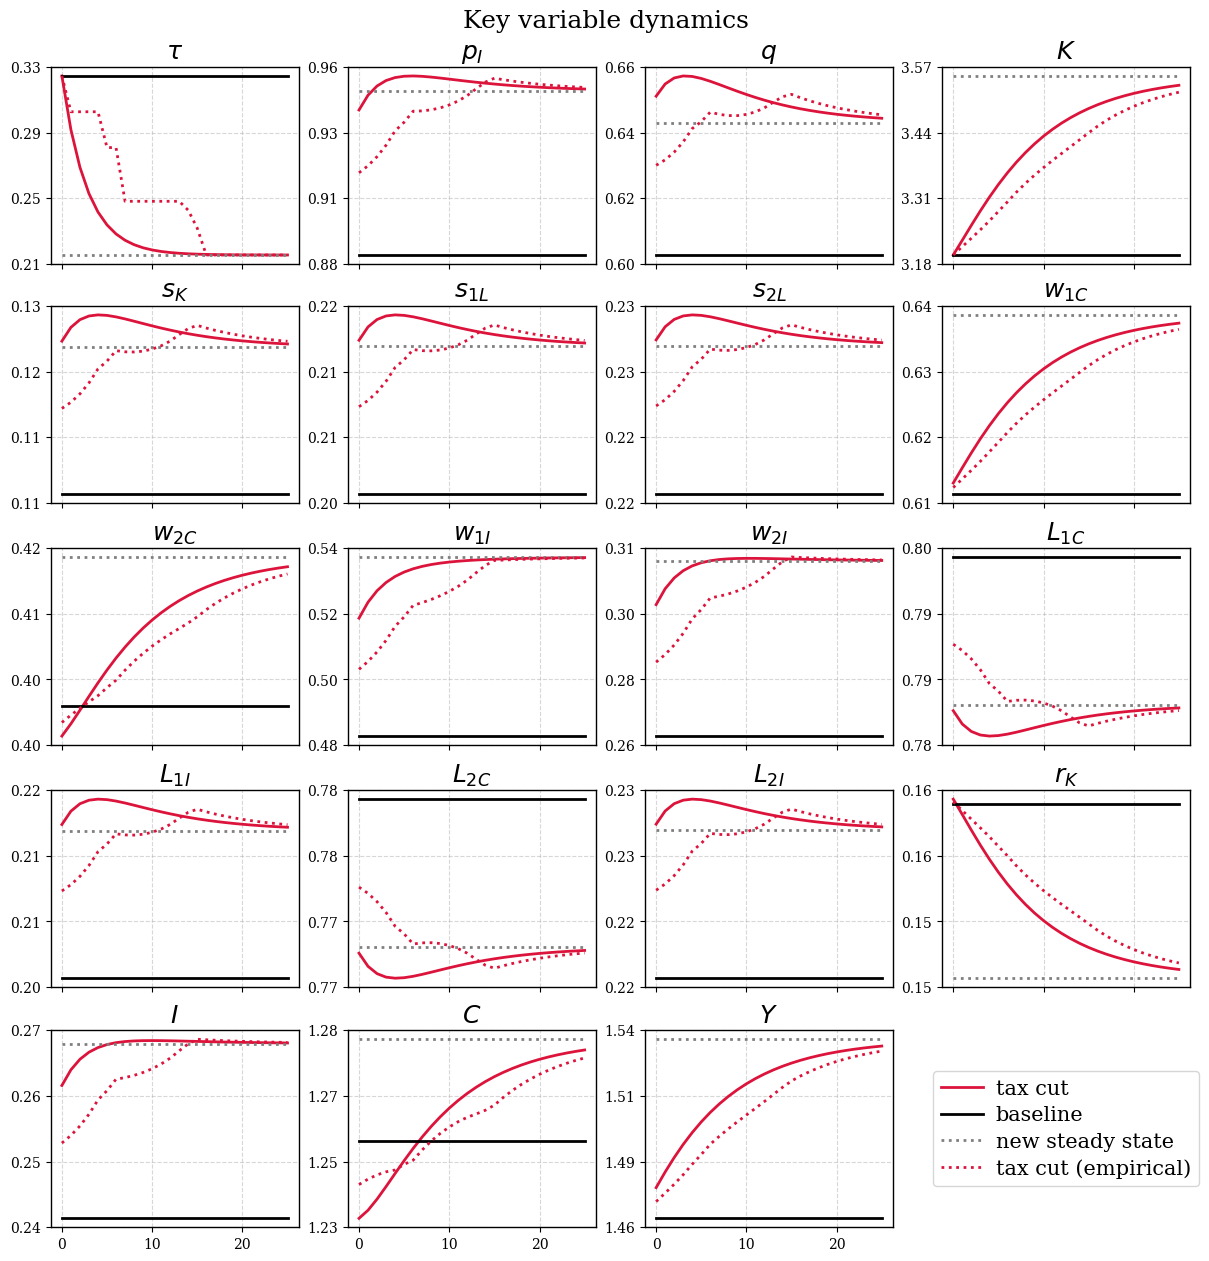

In [48]:
T_plot = 25
sl = slice(0, T_plot + 1)

def trunc_pack(sim, ls):
    S = {**sim, **ls}
    out = {}
    for k, v in S.items():
        a = np.asarray(v)
        out[k] = a[sl] if a.ndim >= 1 and len(a) >= (T_plot + 1) else v
    return out

S1 = trunc_pack(sim1, ls1)
S2 = trunc_pack(sim2, ls2)
S3 = trunc_pack(sim3, ls3)
S4 = trunc_pack(sim4, ls4)

keys = [
    "tau","pI","q","K",
    "sK","s1","s2",
    "w1C","w2C","w1I","w2I",
    "L1C","L1I","L2C","L2I",
    "rC_gross","I","C","Y"
]

# keep only keys that exist in all three
keys = [k for k in keys if (k in S1) and (k in S2) and (k in S3) and (k in S4)]

T = min(
    len(np.asarray(S1[keys[0]])), 
    len(np.asarray(S2[keys[0]])), 
    len(np.asarray(S3[keys[0]])), 
    len(np.asarray(S4[keys[0]]))
)
h = np.arange(T)

ncols = 4
nrows = math.ceil(len(keys) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 2.5*nrows),
    sharex=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()
fig.suptitle('Key variable dynamics')

for i, k in enumerate(keys):
    ax = axes[i]
    ax.plot(h, np.asarray(S1[k])[:T], lw=2, color="crimson")
    ax.plot(h, np.asarray(S2[k])[:T], lw=2, color="k")
    ax.plot(h, np.asarray(S3[k])[:T], lw=2, color="gray", ls=':')
    ax.plot(h, np.asarray(S4[k])[:T], lw=2, color="crimson", ls=':')
    ax.set_title(var_groups.model_var.get(k, k))
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

for ax in axes:
    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)
    
    
# hide any unused panels
for j in range(len(keys), len(axes)):
    axes[j].set_axis_off()

# one legend for the whole figure
axes[0].plot([], [], lw=2, color="crimson", label="tax cut")
axes[0].plot([], [], lw=2, color="k",  label="baseline")
axes[0].plot([], [], lw=2, color="gray", ls=':',  label="new steady state")
axes[0].plot([], [], lw=2, color="crimson", ls=':',  label="tax cut (empirical)")

first_empty = len(keys)

# 2) turn all unused axes off
for j in range(first_empty, len(axes)):
    axes[j].set_axis_off()

# 3) use the first empty one to host the legend
if first_empty < len(axes):
    ax_leg = axes[first_empty]
    ax_leg.set_axis_off()

    # proxy handles (clean + independent of what's plotted)
    h1 = plt.Line2D([0], [0], color="crimson", lw=2)
    h2 = plt.Line2D([0], [0], color="k",  lw=2)
    h3 = plt.Line2D([0], [0], color="crimson", ls=':',  lw=2)
    h3 = plt.Line2D([0], [0], color="gray", ls=':',  lw=2)

    ax_leg.legend(
        [h1, h2, h3, h4], 
        ["tax cut", "baseline", 'new steady state', 'tax cut (empirical)'], 
        loc="center", frameon=True)

plt.show()